# **Импорт библиотек**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gdown

%matplotlib inline

# **Загрузка и подготовка данных**

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)
!unzip -q hw_pro.zip

# **Загрузка изображений**

In [ ]:
base_dir = '/content/hw_pro'
x_train = []
y_train = []
img_height, img_width = 20, 20

for patch in os.listdir(base_dir):
    for img in os.listdir(os.path.join(base_dir, patch)):
        img_path = os.path.join(base_dir, patch, img)
        img_array = image.img_to_array(
            image.load_img(img_path, target_size=(img_height, img_width), color_mode='grayscale')
        )
        x_train.append(img_array)
        # Метки: 0 для крестика (папка '0'), 1 для нолика (папка '1')
        y_train.append(0 if patch == '0' else 1)

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f"Размер массива x_train: {x_train.shape}")
print(f"Размер массива y_train: {y_train.shape}")

Размер массива x_train: (102, 20, 20, 1)
Размер массива y_train: (102,)


# **Подготовка данных**

In [ ]:
# Нормализация
x_train = x_train.astype('float32') / 255.0

# One-hot encoding меток
y_train_cat = utils.to_categorical(y_train, num_classes=2)

# Сглаживание изображений
x_train_flat = x_train.reshape(x_train.shape[0], -1)

# Разделение на train/val
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    x_train_flat, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")

Обучающая выборка: (81, 400)
Валидационная выборка: (21, 400)


# **Построение модели**

In [ ]:
model = Sequential()
model.add(Dense(256, input_dim=400, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,810 (530.51 KB)

 Trainable params: 135,810 (530.51 KB)

 Non-trainable params: 0 (0.00 B)

# **Обучение с EarlyStopping**

In [ ]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    batch_size=16,
    epochs=100,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop],
    verbose=0
)

# **Оценка точности**

In [ ]:
loss, acc = model.evaluate(X_val, y_val_cat, verbose=0)
print(f"\n🎯 Точность на валидационной выборке: {acc:.4f}")

if acc >= 0.95:
    print("✅ Цель достигнута! Точность выше 95%.")
else:
    print("❌ Точность ниже 95%. Попробуйте увеличить сложность модели или изменить гиперпараметры.")


🎯 Точность на валидационной выборке: 1.0000
✅ Цель достигнута! Точность выше 95%.


# **Визуализация обучения**

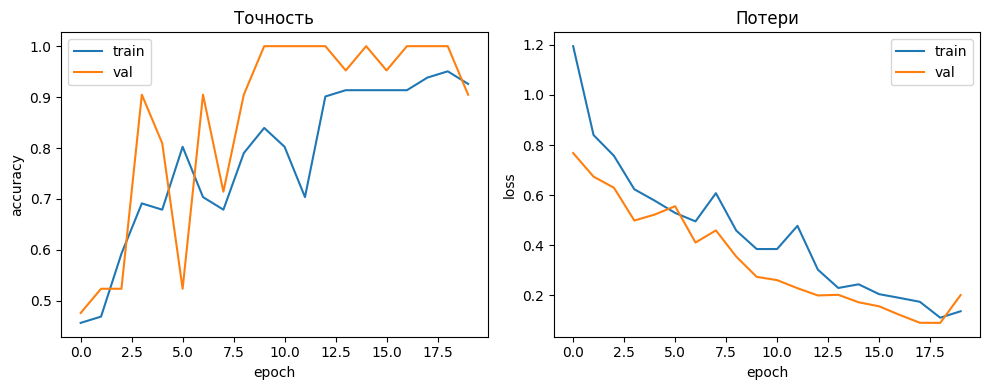

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Точность')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Потери')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
plt.show()